In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as io
from aiapy.calibrate import correct_degradation
from aiapy.calibrate.utils import get_correction_table
from astropy import time
# from astropy import units as u

from sunpy.map import Map
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.coordinates import SkyCoord

from demregpy import dn2dem
from demregpy.tresp import aia_tresp

##############################################################################
# Lets try this on AIA data.

# Load in the SSWIDL generated response functions
# which was produced by make_aiaresp_forpy.pro
trin = io.readsav(aia_tresp)

# Get rid of the byte in the string name
for i in np.arange(len(trin['channels'])):
    trin['channels'][i]=trin['channels'][i].decode("utf-8")

# Get the temperature response functions in the correct form for demreg
tresp_logt=np.array(trin['logt'])
nt=len(tresp_logt)
nf=len(trin['tr'][:])
trmatrix=np.zeros((nt,nf))
for i in range(0,nf):
    trmatrix[:,i]=trin['tr'][i]

# Setup some AIA colours
clrs = ['darkgreen','darkcyan','gold','sienna','indianred','darkslateblue']

time_test = time.Time('2022-02-28T22:30:16', scale='utc')
wavenum=['94','131','171','193','211','335']
nt=16
temperatures=10**np.linspace(5.7,7.1,num=nt+1)
logtemps=np.linspace(5.7,6.3,num=nt+1)
channels = [float(w)*u.angstrom for w in wavenum]
td = time.TimeDelta(11,format='sec')

## Load AIA Data (Local-First, Skip JSOC Export)

AIA files downloaded via JSOC follow the naming convention:
```
aia.lev1_euv_12s.{T_REC}.{WAVELNTH}.image_lev1.fits
```
e.g. `aia.lev1_euv_12s.2022-02-28T223013Z.94.image_lev1.fits`

Within one 12-second cadence, each wavelength has a slightly different `T_REC` (different CCDs fire at different times), but they all fall within the same minute.

**Strategy to avoid redundant JSOC downloads:**
1. For each wavelength, glob-match local files by `{minute}*.{wavelength}` pattern.
2. If multiple cadences exist in the same minute, pick the file closest in time to the target.
3. Only call `Fido.search` + `Fido.fetch` for wavelengths that are missing locally, completely skipping the slow JSOC export link generation when all files already exist.

In [2]:
import glob
import os
from datetime import datetime
from functools import reduce

fdir = '/disk/plasma/xw2/sunpy/data/'
minute_str = time_test.iso[:16].replace(':', '').replace(' ', 'T')
target_dt = datetime.strptime(time_test.iso[:19], '%Y-%m-%d %H:%M:%S')

local_files = {}
missing_wl = []

for wl in wavenum:
    pattern = os.path.join(fdir, f"aia.lev1_euv_12s.{minute_str}*.{wl}.image_lev1.fits")
    matches = sorted(glob.glob(pattern))
    if matches:
        if len(matches) == 1:
            local_files[wl] = matches[0]
        else:
            def _parse_time(f):
                ts = os.path.basename(f).split('.')[2]
                return datetime.strptime(ts, '%Y-%m-%dT%H%M%SZ')
            matches.sort(key=lambda f: abs((_parse_time(f) - target_dt).total_seconds()))
            local_files[wl] = matches[0]
    else:
        missing_wl.append(wl)

if missing_wl:
    print(f"Missing wavelengths locally: {missing_wl}, will download from JSOC...")
    primekeys = [a.jsoc.PrimeKey('WAVELNTH', wl) for wl in missing_wl]
    q = Fido.search(
        a.Time(time_test, time_test + time.TimeDelta(1, format='sec')),
        a.jsoc.Series('aia.lev1_euv_12s'),
        reduce(lambda x, y: x | y, primekeys),
        a.jsoc.Segment('image'),
        a.jsoc.Notify('xiangyu.wu.23@ucl.ac.uk'),
    )
    fetched = Fido.fetch(q, path=fdir + '{file}')
    for f in fetched:
        for wl in missing_wl:
            if f'.{wl}.image_lev1' in str(f):
                local_files[wl] = str(f)
                break
else:
    print(f"All {len(local_files)} AIA files found locally, skipping JSOC export!")

assert len(local_files) == len(wavenum), f"Missing: {set(wavenum) - set(local_files.keys())}"
print("Local files:")
for wl in wavenum:
    print(f"  {wl}A: {os.path.basename(local_files[wl])}")


All 6 AIA files found locally, skipping JSOC export!
Local files:
  94A: aia.lev1_euv_12s.2022-02-28T223013Z.94.image_lev1.fits
  131A: aia.lev1_euv_12s.2022-02-28T223020Z.131.image_lev1.fits
  171A: aia.lev1_euv_12s.2022-02-28T223022Z.171.image_lev1.fits
  193A: aia.lev1_euv_12s.2022-02-28T223018Z.193.image_lev1.fits
  211A: aia.lev1_euv_12s.2022-02-28T223011Z.211.image_lev1.fits
  335A: aia.lev1_euv_12s.2022-02-28T223014Z.335.image_lev1.fits


## 1. Deconvolving images with PSF

1. To deblur the image due to diffraction
2. Deconvolution should be performed before Pointing_Correction

In [3]:
from astropy.coordinates import SkyCoord
from astropy.visualization import ImageNormalize, LogStretch
import aiapy.psf

aia_map = Map(local_files['171'])
psf = aiapy.psf.calculate_psf(aia_map.wavelength)

INFO:2026-03-23 22:22:15,347:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-23 22:22:15 - jax._src.xla_bridge - INFO: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


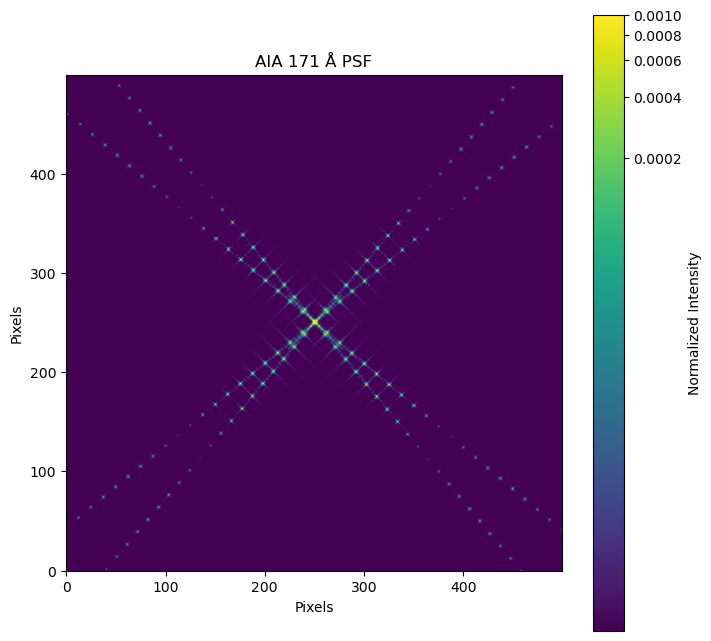

In [4]:
fov = 500
lc_x, lc_y = psf.shape[0] // 2 - fov // 2, psf.shape[1] // 2 - fov // 2
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
ax.imshow(
    psf[lc_x : lc_x + fov, lc_y : lc_y + fov],
    norm=ImageNormalize(vmin=1e-8, vmax=1e-3, stretch=LogStretch()),
    origin="lower",
)
ax.set_title(f"AIA {aia_map.wavelength.value:.0f} Å PSF")
ax.set_xlabel("Pixels")
ax.set_ylabel("Pixels")
plt.colorbar(ax.images[0], ax=ax, label="Normalized Intensity")

In [5]:
aia_map_deconvolved = aiapy.psf.deconvolve(aia_map, psf=psf)

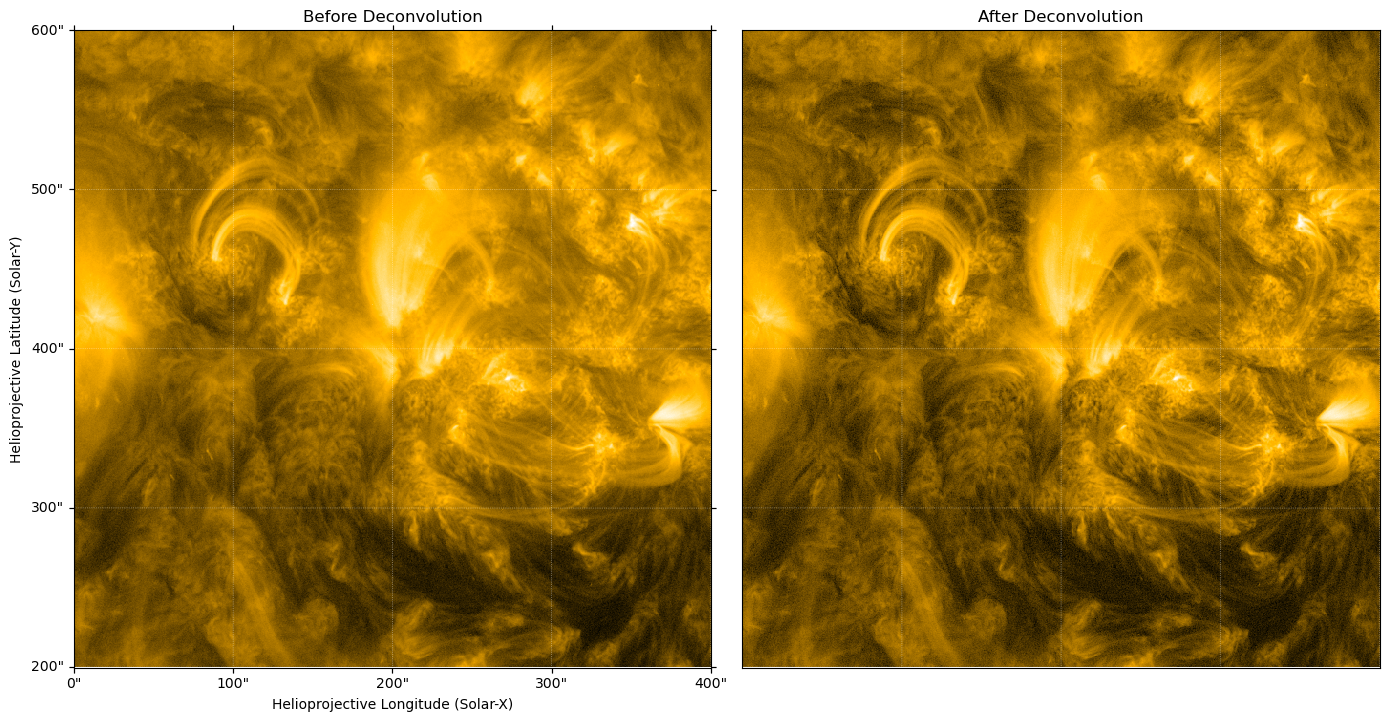

In [15]:
bottom_left = SkyCoord(0, 200, unit="arcsec", frame=aia_map.coordinate_frame)
fov = {"width": 400 * u.arcsec, "height": 400 * u.arcsec}

aia_map_sub = aia_map.submap(bottom_left, **fov)
aia_map_deconvolved_sub = aia_map_deconvolved.submap(bottom_left, **fov)

fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(121, projection=aia_map_sub)
aia_map_sub.plot(axes=ax1, title="Before Deconvolution")
ax2 = fig.add_subplot(122, projection=aia_map_deconvolved_sub)
aia_map_deconvolved_sub.plot(axes=ax2, title="After Deconvolution")
# Just remove the ticks and labels
lon = ax2.coords[0]
lat = ax2.coords[1]
lon.set_ticks_visible(False)
lon.set_ticklabel_visible(False)
lat.set_ticks_visible(False)
lat.set_ticklabel_visible(False)
lon.set_axislabel("")
lat.set_axislabel("")
fig.tight_layout()

## 2. Pointing Correction

1. Performing multi-wavelength analysis on level 1 data can be problematic as each of the AIA channels have slightly different spatial scales and roll angles. 
2. Level 1 data should be updated to the most recent and accurate pointing and interpolated to a common grid in which the y-axis of the image is aligned with solar North.

In [19]:
from aiapy.calibrate import register, update_pointing
from aiapy.calibrate.utils import get_pointing_table


# Make range wide enough to get closest 3-hour pointing
pointing_table = get_pointing_table("JSOC", time_range=(aia_map.date - 12 * u.h, aia_map.date + 12 * u.h))
aia_map_updated_pointing = update_pointing(aia_map_deconvolved, pointing_table=pointing_table)
print(aia_map_updated_pointing.scale)
print(aia_map_updated_pointing.rotation_matrix)

aia_map_registered = register(aia_map_updated_pointing)
print(aia_map_registered.scale)
print(aia_map_registered.rotation_matrix)

SpatialPair(axis1=<Quantity 0.599489 arcsec / pix>, axis2=<Quantity 0.599489 arcsec / pix>)
[[ 9.99999943e-01 -3.37743793e-04]
 [ 3.37743793e-04  9.99999943e-01]]
SpatialPair(axis1=<Quantity 0.6 arcsec / pix>, axis2=<Quantity 0.6 arcsec / pix>)
[[ 1.00000000e+00 -5.71926235e-21]
 [-2.24322744e-20  1.00000000e+00]]


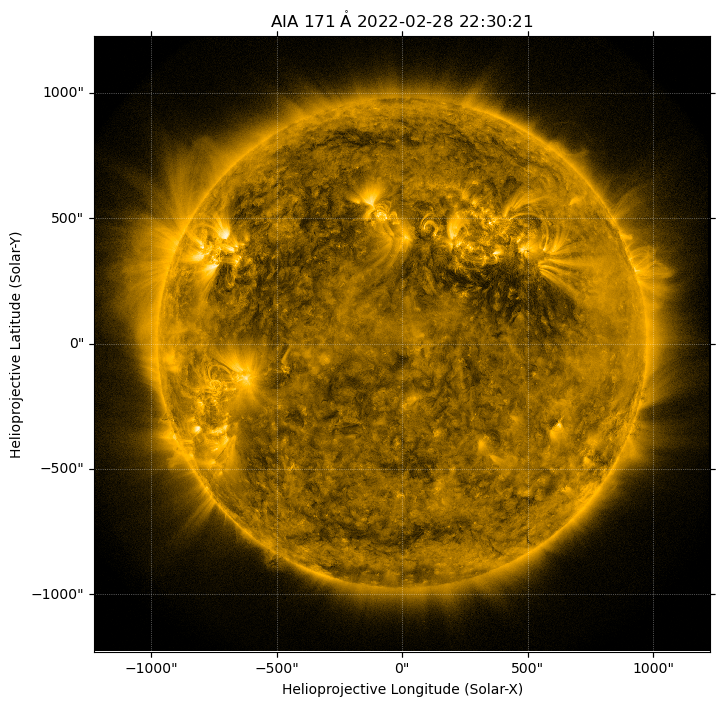

In [22]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(projection=aia_map_registered)
aia_map_registered.plot(axes=ax)
plt.show()

## 3. Degradation Correction & Exposure time normalizatio

In [ ]:
correction_table = get_correction_table()

date_obs = aia_map_registered.date
datamean = np.mean(aia_map_registered.data) * u.DN
wavelength = aia_map_registered.wavelength

aia_map_corrected = correct_degradation(aia_map_registered, correction_table=correction_table)
datamean_corrected = np.mean(aia_map_corrected.data) * u.DN

print(f"Wavelength:       {wavelength}")
print(f"DATE_OBS:         {date_obs}")
print(f"Mean DN (raw):    {datamean:.2f}")
print(f"Mean DN (corr):   {datamean_corrected:.2f}")
print(f"Correction ratio: {datamean_corrected / datamean:.4f}")

aia_map_prepared = aia_map_corrected / aia_map.exposure_time

Wavelength:       171.0 Angstrom
DATE_OBS:         2022-02-28T22:30:21.350
Mean DN (raw):    159.52 DN
Mean DN (corr):   222.68 DN
Correction ratio: 1.3959


 **So far, all corrections have been completed!**

## 4. Save pre-processed AIA image

**Note on `BLANK` keyword warning:** The original AIA Level 1 FITS header contains a `BLANK` keyword for flagging invalid pixels in integer data. After calibration (deconvolution, registration, degradation correction, exposure normalization), the image data becomes floating-point. The FITS standard only allows `BLANK` for integer HDUs, so Astropy warns and ignores it. This is harmless — the saved file and its data are correct.

In [32]:
save_dir = '/disk/plasma/xw2/sunpy/data/aia_prep/'
os.makedirs(save_dir, exist_ok=True)

wl = int(aia_map_prepared.wavelength.value)
date_str = aia_map_prepared.date.strftime('%Y%m%d_%H%M%S')
save_path = os.path.join(save_dir, f'aia_prep_{wl}A_{date_str}.fits')

aia_map_prepared.save(save_path, overwrite=True)
print(f"Saved: {save_path}")
print(f"  Shape: {aia_map_prepared.data.shape}")
print(f"  Wavelength: {aia_map_prepared.wavelength}")
print(f"  Date: {aia_map_prepared.date}")

2026-03-23 23:11:32 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.


Saved: /disk/plasma/xw2/sunpy/data/aia_prep/aia_prep_171A_20220228_223021.fits
  Shape: (4094, 4094)
  Wavelength: 171.0 Angstrom
  Date: 2022-02-28T22:30:21.350
